# Magnet Ramp Analysis

In [59]:
## General purpose
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.axes as axes
import scipy as sp
import scipy.fft
import scipy.optimize as sp
import os
import time
import datetime
import scipy.signal
import matplotlib.colors as cls
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import importlib
import pprint
import glob
import re
from scipy import stats
import qcodes as qc
import sys
from scipy import stats
import scipy.signal as peak
import matplotlib.colors as colors

# Directory structure
current_file = 'magnet ramp.ipynb'
current_dir = os.path.dirname(os.path.abspath(current_file)) # Angela Experiments
print(current_dir)
parent_dir = os.path.dirname(current_dir) # Longterm_sweeps
print(parent_dir)

# Append parent directory (longterm_sweeps) to sys.path -> search for files in this branch
sys.path.append(r"C:\Users\Mario\Documents\GitHub\Drivers")

# Import functions!!
import qil_helpers.Angela.angelaHelpers as ang 

c:\Users\Mario\Documents\GitHub\longterm_sweeps\analysis
c:\Users\Mario\Documents\GitHub\longterm_sweeps


## Functions

In [ ]:
# PIEZO COLLECT BY FIELD
def collect_piezo_by_field(flds_directory, sites, aom, num_bins, ylim):
    """
    Returns:
        all_freqsVpeaks[field][site] = DataFrame
    """
    all_freqsVpeaks = {}
    timeLimit = None

    for fld_directory in flds_directory:
        field_key = os.path.basename(os.path.normpath(fld_directory))
        all_freqsVpeaks[field_key] = {}
        sites_directory = sorted(os.listdir(fld_directory))
        for site in sites_directory:
            site_key = os.path.basename(os.path.normpath(site))
            site_path = os.path.join(fld_directory, site)
            files = sorted(
                [f for f in os.listdir(site_path) if f.endswith(".csv")],
                key=lambda f: float(f.split("_")[2])) # assumes freq in filename
            freqs = []
            peaks = []
            pVs = []
            is_saturated = []

            for file in files:
                file_path = os.path.join(site_path, file)
                file_read = np.loadtxt(file_path, delimiter=",")
                times, data = file_read[0], file_read[1]

                # Extract metadata from filename
                parts = file.split("_")
                freq = float(parts[2]) + aom * 1e3   # MHz
                pV = float(parts[-2])
                counts = np.sum(data[:num_bins + 1])
                maxLim = ylim[1]
                if timeLimit is None:
                    timeLimit = float(times[num_bins])
                freqs.append(freq)
                peaks.append(counts)
                pVs.append(pV)
                is_saturated.append(counts > maxLim)

            # Build DataFrame
            df = pd.DataFrame({
                "Frequencies (MHz)": freqs,
                f"Counts over {timeLimit*1e3} ms": peaks,
                "Piezo Voltage (V)": pVs,
                "Saturated": is_saturated})
            df = df.sort_values("Frequencies (MHz)").reset_index(drop=True)

            # Store in hierarchy
            if site_key not in all_freqsVpeaks:
                all_freqsVpeaks[site_key] = {}
            all_freqsVpeaks[site_key][field_key] = df

    return all_freqsVpeaks, timeLimit

# MOTOR COLLECT BY FIELD
def collect_motor_by_field(flds_directory, sites, aom, num_bins, ylim):
    """
    Returns:
        all_freqsVpeaks[field][site] = DataFrame
    """
    all_freqsVpeaks = {}
    timeLimit = None

    for fld_directory in flds_directory:
        field_key = os.path.basename(os.path.normpath(fld_directory))
        all_freqsVpeaks[field_key] = {}

        # Get site folders
        sites_directory = sorted(os.listdir(fld_directory))

        for site in sites_directory:
            site_key = os.path.basename(os.path.normpath(site))
            site_path = os.path.join(fld_directory, site)
            files = sorted(
                [f for f in os.listdir(site_path) if f.endswith(".csv")],
                key=lambda f: float(f.split("_")[2])  # assumes freq in filename
            )

            freqs = []
            peaks = []
            is_saturated = []

            for file in files:
                file_path = os.path.join(site_path, file)
                file_read = np.loadtxt(file_path, delimiter=",")
                times, data = file_read[0], file_read[1]

                # Extract metadata from filename
                parts = file.split("_")
                freq = float(parts[2]) + aom * 1e3   # MHz
                counts = np.sum(data[:num_bins + 1])
                maxLim = ylim[1]

                if timeLimit is None:
                    timeLimit = float(times[num_bins])

                freqs.append(freq)
                peaks.append(counts)
                is_saturated.append(counts > maxLim)

            # Build DataFrame
            df = pd.DataFrame({
                "Frequencies (MHz)": freqs,
                f"Counts over {timeLimit*1e3} ms": peaks,
                "Saturated": is_saturated})
            df = df.sort_values("Frequencies (MHz)").reset_index(drop=True)

            # Store in hierarchy
            if site_key not in all_freqsVpeaks:
                all_freqsVpeaks[site_key] = {}
            all_freqsVpeaks[site_key][field_key] = df

    return all_freqsVpeaks, timeLimit

def process_colourmap(site_data):
    """
    Input:
        site_data[field] = DataFrame

    Returns:
        counts_matrix (freq x field),
        fields (sorted),
        freqs,
        centre_freqs
    """

    # Sort fields numerically
    fields = np.array([float(k.replace("A", "")) for k in site_data.keys()])
    sorted_idx = np.argsort(fields)
    fields = fields[sorted_idx]
    sorted_keys = np.array(list(site_data.keys()))[sorted_idx]

    # Assume same frequency axis across fields
    freqs = site_data[sorted_keys[0]]["Frequencies (MHz)"].values
    counts_matrix = np.zeros((len(freqs), len(fields)))
    freqs_matrix = np.zeros((len(freqs), len(fields)))

    for i, key in enumerate(sorted_keys):
        df = site_data[key]
        counts_matrix[:, i] = df.iloc[:, 1].values
        freqs_matrix[:, i] = df["Frequencies (MHz)"].values

    return counts_matrix, freqs_matrix, fields, freqs

# Import Data

In [300]:
# Import data 
folders_0216 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\2026-02-16\confocal_field_ramp\run1\*'))
folders_0220_run3 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\2026-02-20\confocal_field_ramp\run3\*'))
folders_0220_run6 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\2026-02-20\confocal_field_ramp\run6\*'))
folders_0318 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\2026-03-18\confocal_field_ramp\run6\*'))
folders_0326 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\2026-03-26\confocal_field_ramp\run10\*'))


# CaF2

In [160]:
## Default: [frequency (THz), wavelength (nm), label]
CaF_trn = {
    'A_Z1Y1': [197.05, 1521.296, r'A: $Z_1 \to Y_1$'],
    'G1_Z1Y1': [197.4686, 1518.070, r'G1: $Z_1 \to Y_1$'],
    'A_Z1Y2': [197.913, 1514.664, r'A: $Z_1 \to Y_2$'],
    'G1_Z1Y2': [198.2567, 1512.037, r'G1: $Z_1 \to Y_2$'],
    'B_Z1Y1': [198.76215, 1508.195, r'B: $Z_1 \to Y_1$'],
    'Cube_Z1Y1': [198.927, 1506.945, r'Cubic: $Z_1 \to Y_1$'],
    'Cube_Z1Y2':[199.242, 1504.563, r'Cubic: $Z_1 \to Y_2$']
    }

In [162]:
CaF_all_freqsVpeaks, CaF_timeLimit = collect_piezo_by_field(folders_0220_run6, 
                                          sites = CaF_trn, 
                                          aom = 0.380, 
                                          num_bins = 40, 
                                          ylim = [0, 4e3])

Site A: $Z_1 \to Y_1$ at 197.05 THz


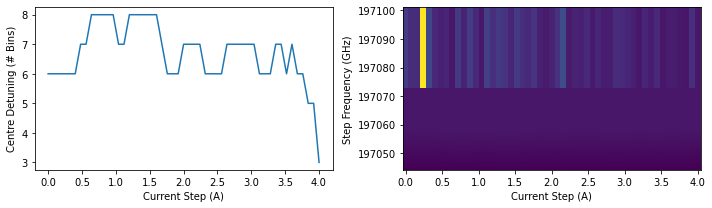

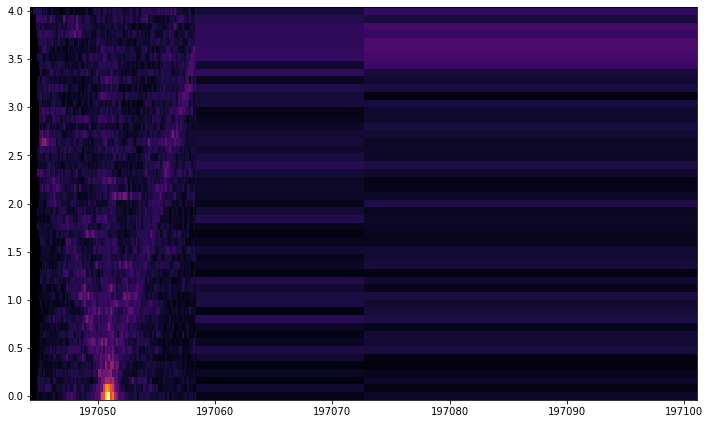

Site G1: $Z_1 \to Y_1$ at 197.4686 THz


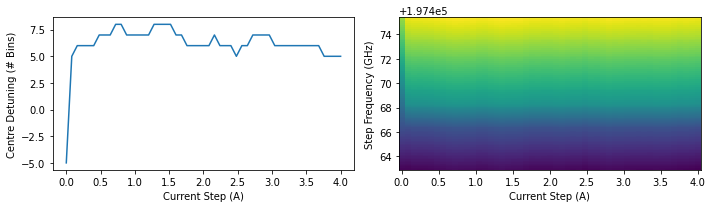

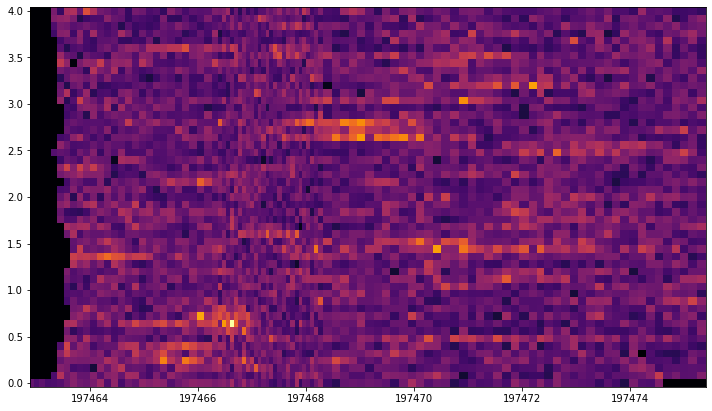

Site A: $Z_1 \to Y_2$ at 197.913 THz


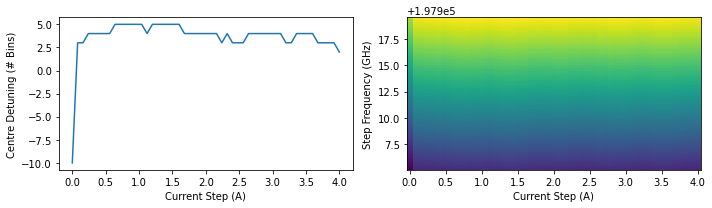

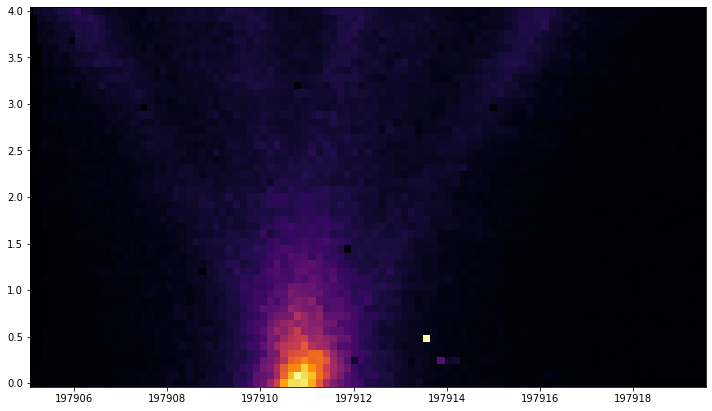

Site G1: $Z_1 \to Y_2$ at 198.2567 THz


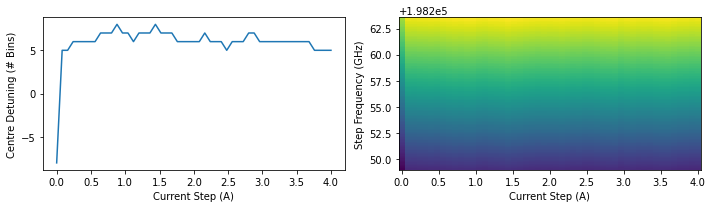

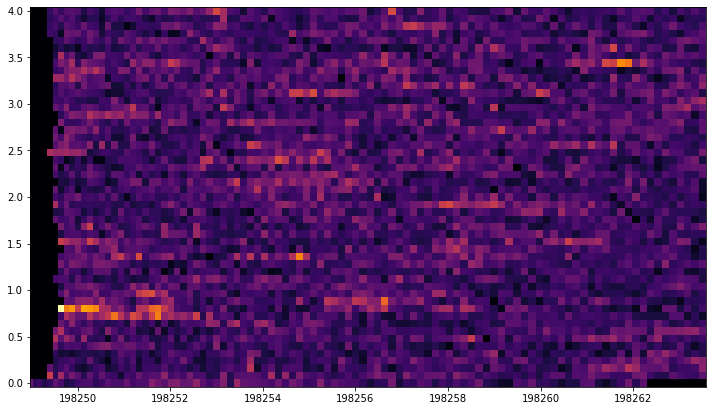

Site B: $Z_1 \to Y_1$ at 198.76215 THz


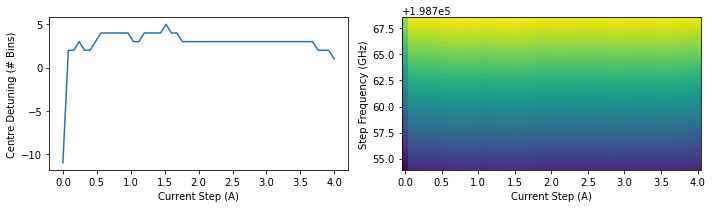

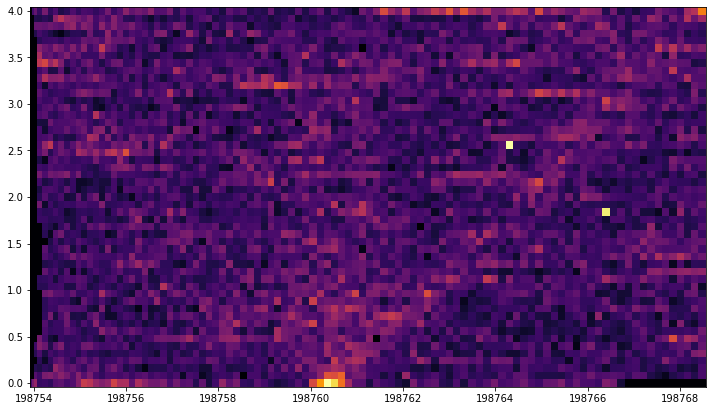

Site Cubic: $Z_1 \to Y_1$ at 198.927 THz


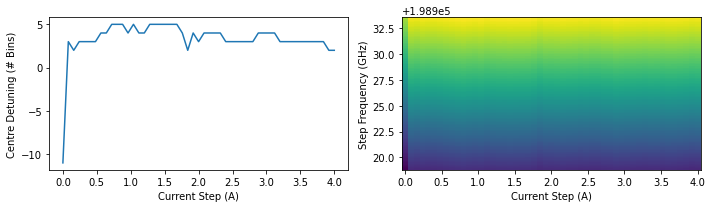

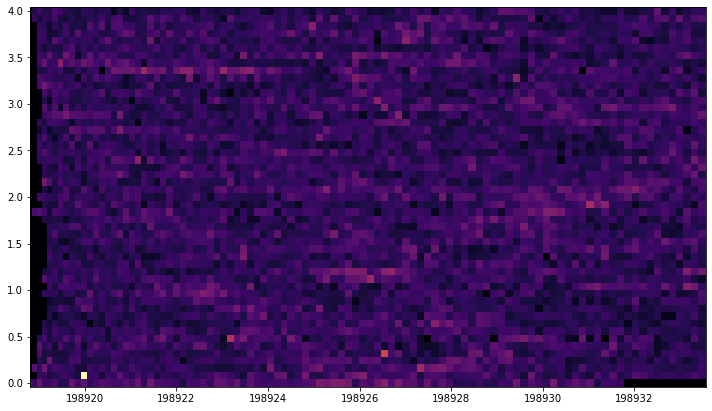

Site Cubic: $Z_1 \to Y_2$ at 199.242 THz


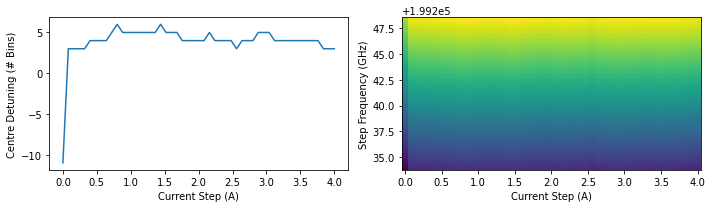

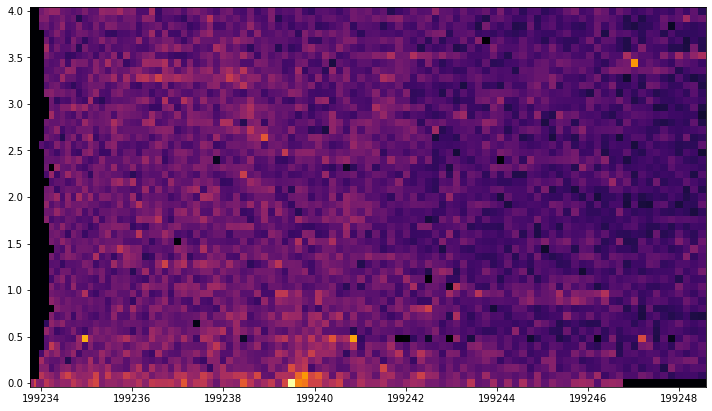

In [262]:
countLims = [2e3, 2e3, 3e4, 9.2e2, 7e2, 1.8e3, 7.6e2]

for i, site in enumerate(CaF_trn):
    # ID each site 
    site = CaF_trn[f'{site}']
    wavelength = site[1]
    siteData = CaF_all_freqsVpeaks[f'{wavelength:.3f}']
    print(f'Site {site[2]} at {site[0]} THz')

    # Process to extract data
    counts_matrix, freqs_matrix, fields, freqs = process_colourmap(siteData)

    # Plot average centre frequency for each piezo scan at field
    fig, ax = plt.subplots(1, 2, figsize = (10, 3), sharey = False)
    centre_freqs = np.median(freqs_matrix, axis = 0)
    detuned_freqs = (centre_freqs - site[0]*1e6)
    bin_width = abs(freqs_matrix[:, 50][-1] - freqs_matrix[:, 50][0])/len(freqs_matrix[:, 50])
    detuned_bins = np.floor(detuned_freqs/bin_width) # Round detuning to number of bins in frequency
    ax1 = ax[0]
    ax1.plot(fields, detuned_bins)
    ax1.set_xlabel('Current Step (A)')
    ax1.set_ylabel('Centre Detuning (# Bins)')
    plt.tight_layout()

    # Plot centre frequency drift
    ax2 = ax[1]
    ax2.pcolormesh(fields, freqs/1e3, freqs_matrix, cmap = 'viridis')
    ax2.set_xlabel('Current Step (A)')
    ax2.set_ylabel('Step Frequency (GHz)')
    plt.tight_layout()
    plt.show() 

    # Account for piezo drift by shifting columns
    shift_spectrum = np.zeros_like(counts_matrix)
    n_rows, n_cols = shift_spectrum.shape
    for j in range(n_cols):
        shift = int(detuned_bins[j])
        col = counts_matrix[:, j]
        if shift > 0:  # shift down
            shift_spectrum[shift:, j] = col[:-shift]
        elif shift < 0:  # shift up
            shift_spectrum[:shift, j] = col[-shift:]
        else:
            shift_spectrum[:, j] = col
    counts_matrix = shift_spectrum

    # Filter for outliers
    counts_matrix[counts_matrix > countLims[i]] = 0
    
    # Plot Zeeman spectrum
    plt.figure(figsize = (10, 6))
    plt.pcolormesh(freqs/1e3, fields, counts_matrix.T, cmap = 'inferno', norm = colors.PowerNorm(gamma = 1.1))
    # plt.colorbar()
    plt.tight_layout()
    plt.ticklabel_format(useOffset = False, style = 'plain', axis = 'both')
    plt.show()

# SiC

In [5]:
SiC_trn = {
    'A': [196.088, 1528.767, r'A'],
    'B': [196.900, 1522.469, r'B'],
    'C': [197.527, 1517.640, r'C']
    }

In [272]:
SiC_all_freqsVpeaks, SiC_timeLimit = collect_motor_by_field(folders_0318, 
                                          sites = SiC_trn, 
                                          aom = 0.380, 
                                          num_bins = 150, 
                                          ylim = [0, 4e3])

In [259]:
print(fr"{SiC_timeLimit*1e3} ms")

3.0 ms


Site A at 196.088 THz


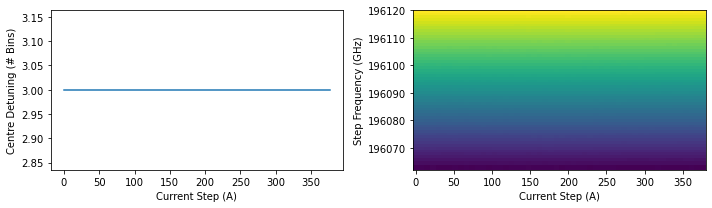

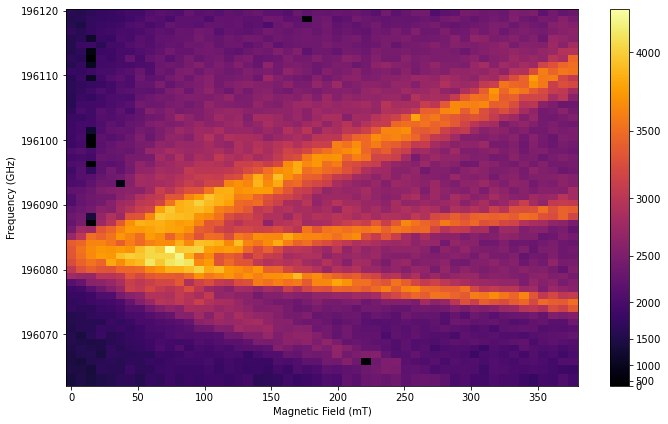

Site B at 196.900 THz


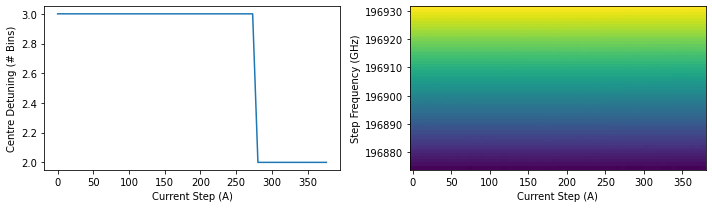

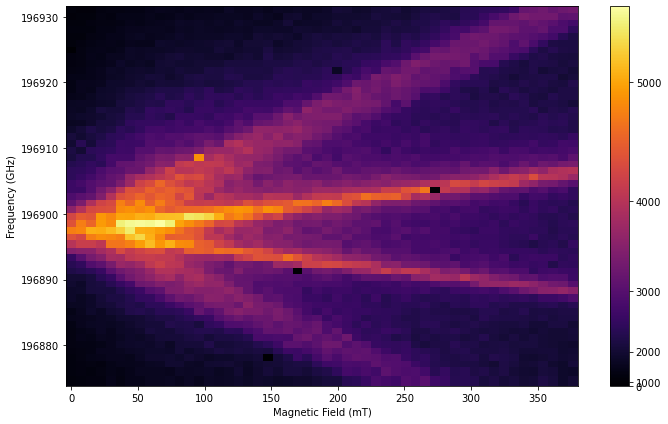

Site C at 197.527 THz


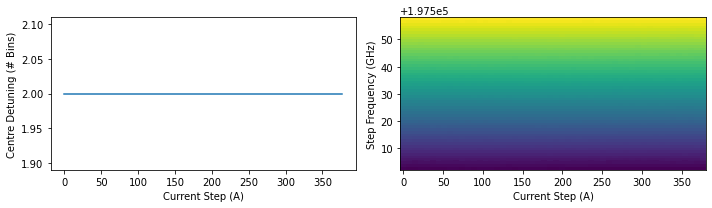

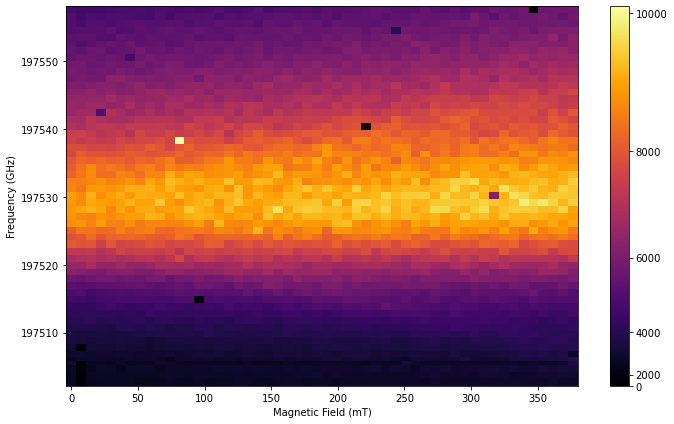

In [337]:
countLims = [1e8, 1e8, 1e8]*100
mango_cc = 24.6 # mT/A

for i, site in enumerate(SiC_trn):
    # ID each site 
    site = SiC_trn[f'{site}']
    wavelength = site[1]
    siteData = SiC_all_freqsVpeaks[f'{wavelength:.3f}']
    print(f'Site {site[2]} at {site[0]:.3f} THz')
    
    # Process to extract data
    counts_matrix, freqs_matrix, currents, freqs = process_colourmap(siteData)
    fields = currents * mango_cc

    # Plot average centre frequency for each piezo scan at field
    fig, ax = plt.subplots(1, 2, figsize = (10, 3), sharey = False)
    centre_freqs = np.median(freqs_matrix, axis = 0)
    detuned_freqs = (centre_freqs - site[0]*1e6)
    bin_width = abs(freqs_matrix[:, 50][-1] - freqs_matrix[:, 50][0])/len(freqs_matrix[:, 50])
    detuned_bins = np.floor(detuned_freqs/bin_width) # Round detuning to number of bins in frequency
    ax1 = ax[0]
    ax1.plot(fields, detuned_bins)
    ax1.set_xlabel('Current Step (A)')
    ax1.set_ylabel('Centre Detuning (# Bins)')
    plt.tight_layout()

    # Plot centre frequency drift
    ax2 = ax[1]
    ax2.pcolormesh(fields, freqs/1e3, freqs_matrix, cmap = 'viridis')
    ax2.set_xlabel('Current Step (A)')
    ax2.set_ylabel('Step Frequency (GHz)')
    plt.tight_layout()
    plt.show() 

    # # Account for piezo drift by shifting columns
    # shift_spectrum = np.zeros_like(counts_matrix)
    # n_rows, n_cols = shift_spectrum.shape
    # for j in range(n_cols):
    #     shift = int(detuned_bins[j])
    #     col = counts_matrix[:, j]
    #     if shift > 0:  # shift down
    #         shift_spectrum[shift:, j] = col[:-shift]
    #     elif shift < 0:  # shift up
    #         shift_spectrum[:shift, j] = col[-shift:]
    #     else:
    #         shift_spectrum[:, j] = col
    # counts_matrix = shift_spectrum

    # Filter for outliers
    counts_matrix[counts_matrix > countLims[i]] = 0
    
    # Plot Zeeman spectrum
    plt.figure(figsize = (10, 6))
    plt.pcolormesh(fields, freqs/1e3, counts_matrix, cmap = 'inferno', norm = colors.PowerNorm(gamma = 2))
    plt.xlabel('Magnetic Field (mT)')
    plt.ylabel('Frequency (GHz)')
    plt.ticklabel_format(useOffset = False, style = 'plain', axis = 'both')
    plt.colorbar()
    plt.tight_layout()
    plt.show()

In [301]:
SiC_trn_C = {
    'C': [197.527, 1517.640, r'C']
    }

In [302]:
SiC_all_freqsVpeaks_C, SiC_timeLimit_C = collect_motor_by_field(folders_0326, 
                                          sites = SiC_trn_C, 
                                          aom = 0.380, 
                                          num_bins = 150, 
                                          ylim = [0, 4e3])

In [303]:
print(fr"{SiC_timeLimit_C*1e3} ms")

3.0 ms


Site C at 197.527 THz


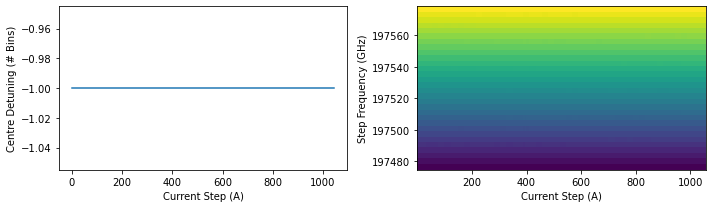

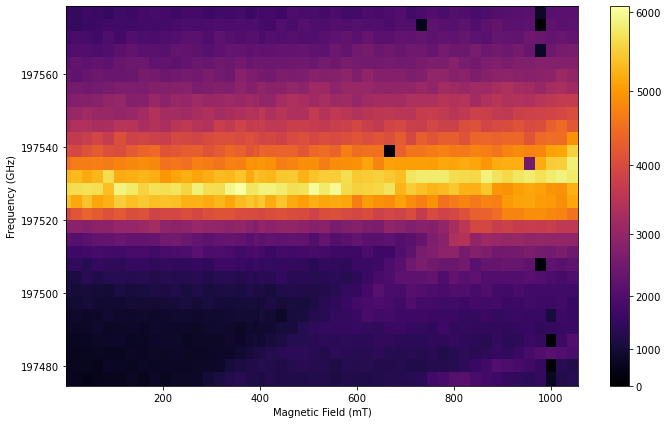

In [341]:
countLims_C = [1e12]
mango_cc = 24.6 # mT/A

for i, site in enumerate(SiC_trn_C):
    # ID each site 
    site = SiC_trn_C[f'{site}']
    wavelength = site[1]
    siteData_C = SiC_all_freqsVpeaks_C[f'{wavelength:.3f}']
    # del siteData_C['43.37879641A'] # remove quench
    print(f'Site {site[2]} at {site[0]:.3f} THz')
    
    # Process to extract data
    counts_matrix, freqs_matrix, currents, freqs = process_colourmap(siteData_C)

    # Plot average centre frequency for each piezo scan at field
    fig, ax = plt.subplots(1, 2, figsize = (10, 3), sharey = False)
    centre_freqs = np.median(freqs_matrix, axis = 0)
    detuned_freqs = (centre_freqs - site[0]*1e6)
    bin_width = abs(freqs_matrix[:, 50][-1] - freqs_matrix[:, 50][0])/len(freqs_matrix[:, 50])
    detuned_bins = np.floor(detuned_freqs/bin_width) # Round detuning to number of bins in frequency
    ax1 = ax[0]
    fields = currents * mango_cc
    ax1.plot(fields, detuned_bins)
    ax1.set_xlabel('Current Step (A)')
    ax1.set_ylabel('Centre Detuning (# Bins)')
    plt.tight_layout()

    # Plot centre frequency drift
    ax2 = ax[1]
    ax2.pcolormesh(fields, freqs/1e3, freqs_matrix, cmap = 'viridis')
    ax2.set_xlabel('Current Step (A)')
    ax2.set_ylabel('Step Frequency (GHz)')
    plt.tight_layout()
    plt.show() 

    # Filter for outliers
    counts_matrix[counts_matrix > countLims_C[i]] = 0
    
    # Plot Zeeman spectrum
    plt.figure(figsize = (10, 6))
    cm = plt.pcolormesh(fields, freqs/1e3, counts_matrix, cmap = 'inferno', norm = colors.PowerNorm(gamma = 1.3))
    # cm.set_clim(0, 8e3)
    plt.xlabel('Magnetic Field (mT)')
    plt.ylabel('Frequency (GHz)')
    plt.ticklabel_format(useOffset = False, style = 'plain', axis = 'both')
    plt.colorbar(cm)
    plt.tight_layout()
    plt.show()